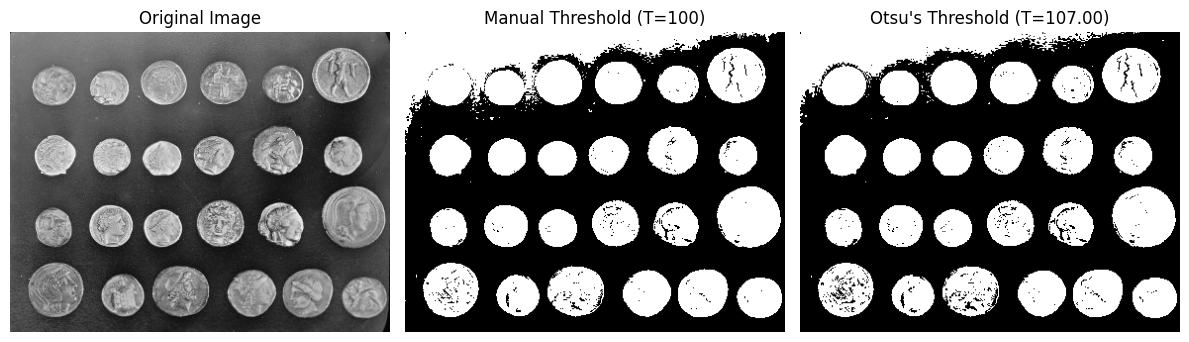

Nilai threshold Otsu yang ditemukan: 107


In [1]:
# Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.color import rgb2gray

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()  # Citra sudah grayscale

# 2. Thresholding Global (manual)
# Tentukan nilai ambang manual, misal 100
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\'s Threshold (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

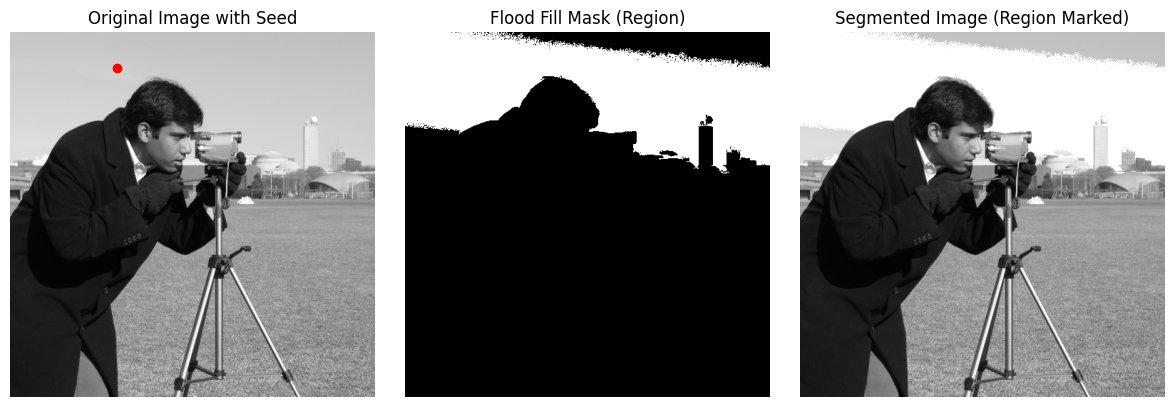

In [ ]:
# Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation

# 1. Load image (example: camera)
image_camera = data.camera()

# 2. Define seed point
# Example: point at y=50, x=150
seed_point = (50, 150)

# 3. Apply flood fill algorithm (similar to region growing)
# 'tolerance' determines allowed intensity difference
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Create segmented image (mark the grown region)
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255  # Mark region with white

# 5. Visualize results
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro')  # Mark seed point
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

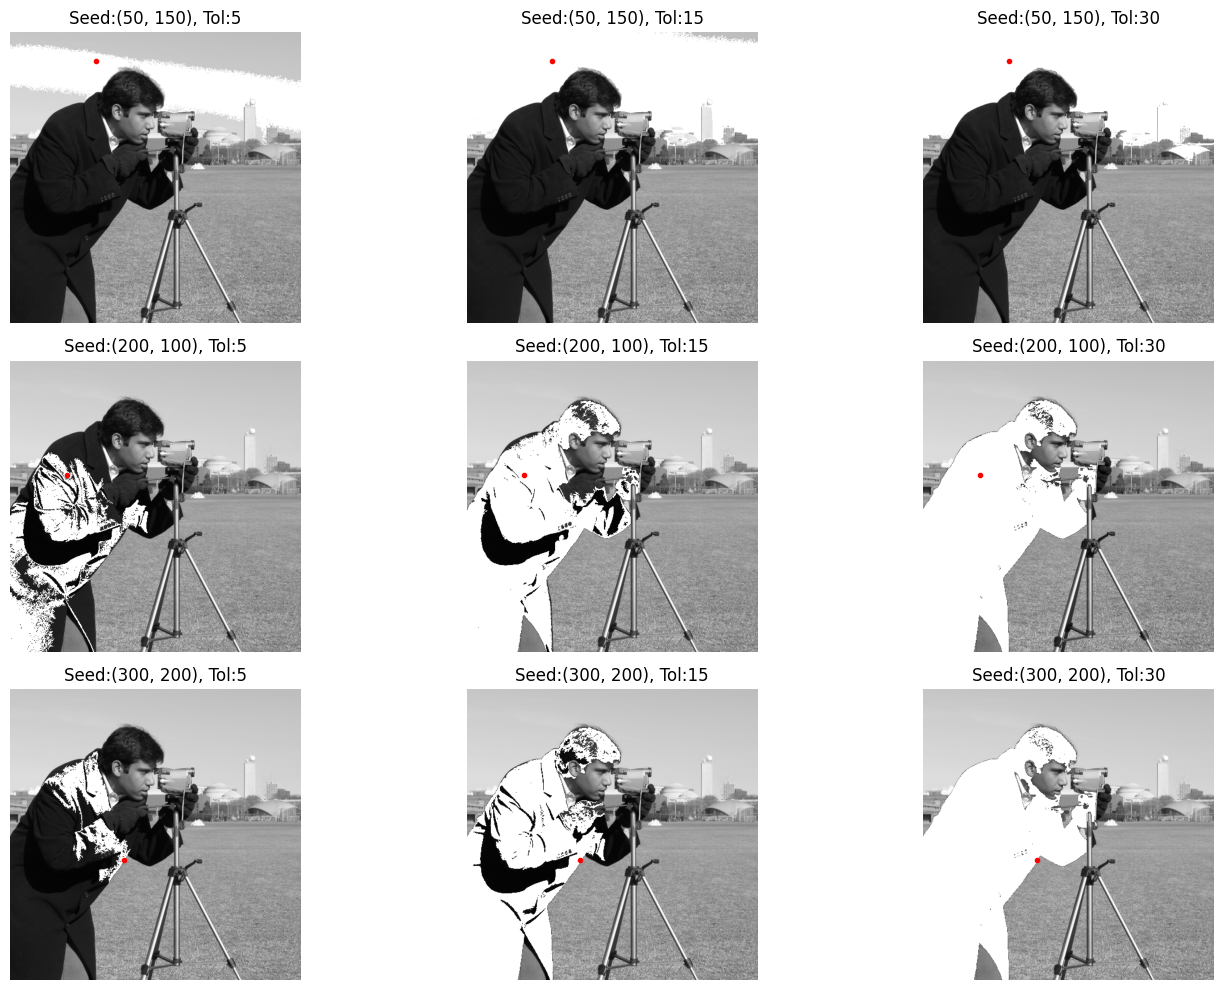

In [ ]:
# Soal Praktikum 2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation

image = data.camera()

# Uji coba parameter berbeda
seed_points = [(50, 150), (200, 100), (300, 200)]  # Titik seed alternatif
tolerances = [5, 15, 30]  # Nilai tolerance berbeda

fig, axes = plt.subplots(len(seed_points), len(tolerances), figsize=(15, 10))

for i, seed in enumerate(seed_points):
    for j, tol in enumerate(tolerances):
        mask = segmentation.flood(image, seed, tolerance=tol)
        segmented = np.copy(image)
        segmented[mask] = 255
        
        axes[i,j].imshow(segmented, cmap='gray')
        axes[i,j].plot(seed[1], seed[0], 'ro', markersize=3)
        axes[i,j].set_title(f"Seed:{seed}, Tol:{tol}")
        axes[i,j].axis('off')

plt.tight_layout()
plt.show()

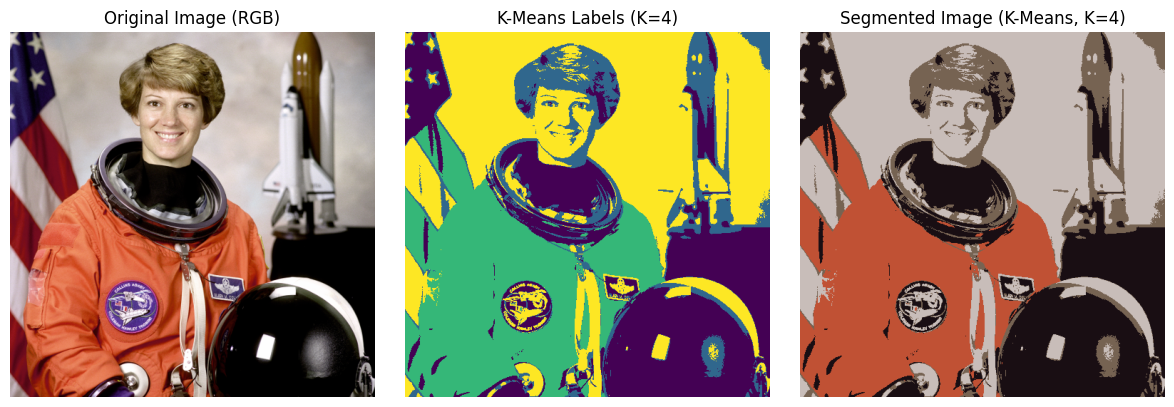

In [ ]:
# Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Load color image (example: astronaut)
image_astro = data.astronaut()
image_astro_float = image_astro.astype(float) / 255.0  # Convert to float for calculations

# 2. Reshape image into pixel array [num_pixels, num_features]
# Using Lab color space which is better for color perception
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Apply K-Means Clustering
n_clusters = 4  # Number of segments
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

# Hide FutureWarnings related to default value of n_init
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Reshape labels back to image shape
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Create segmented image (color each segment with cluster mean color)
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_

for k in range(n_clusters):
    # Get pixels belonging to cluster k
    cluster_pixels = (pixel_labels == k)
    # Fill these pixels in new image with cluster center color
    mask_k = cluster_pixels.reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Convert back to RGB for display
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualize Results
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

# Show cluster labels
ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

# Show K-Means segmented image
ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

=== Hasil Segmentasi di Ruang Lab ===


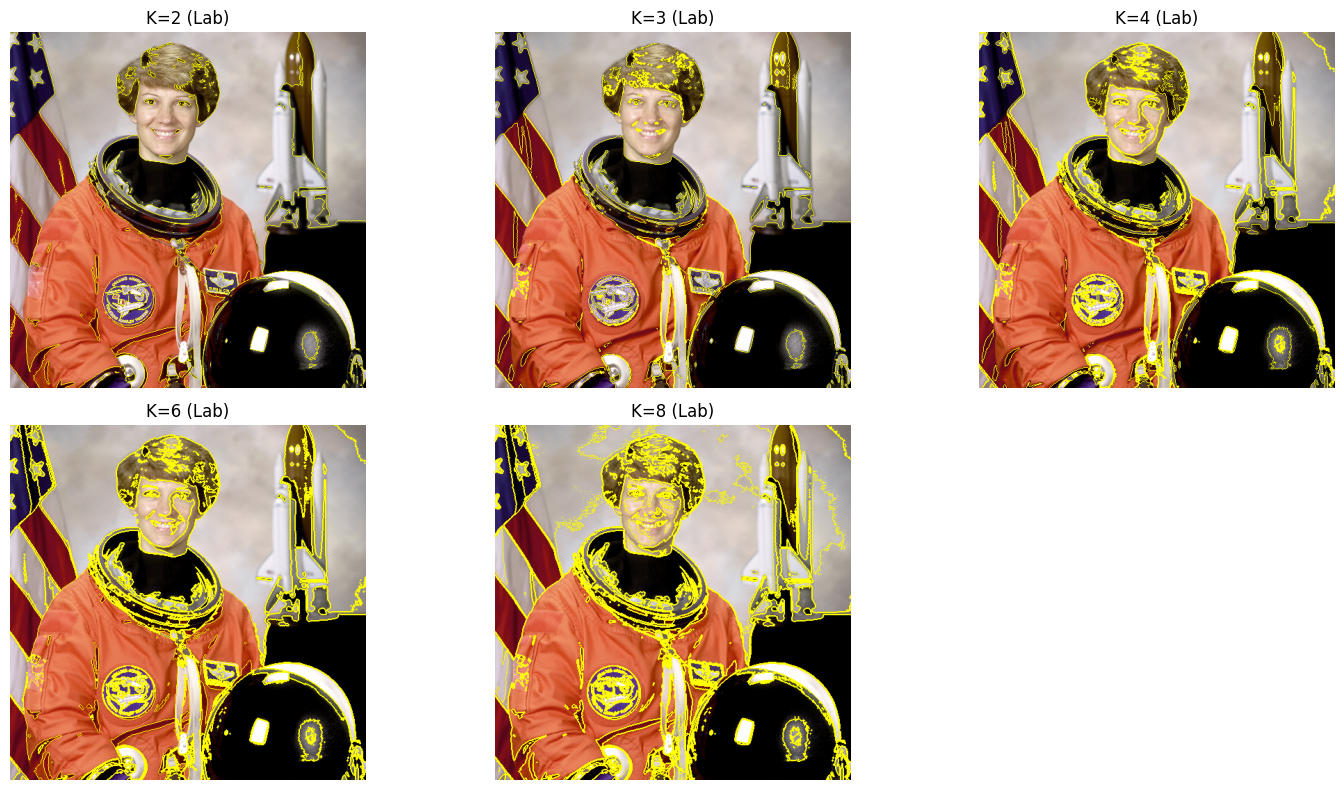


=== Hasil Segmentasi di Ruang RGB ===


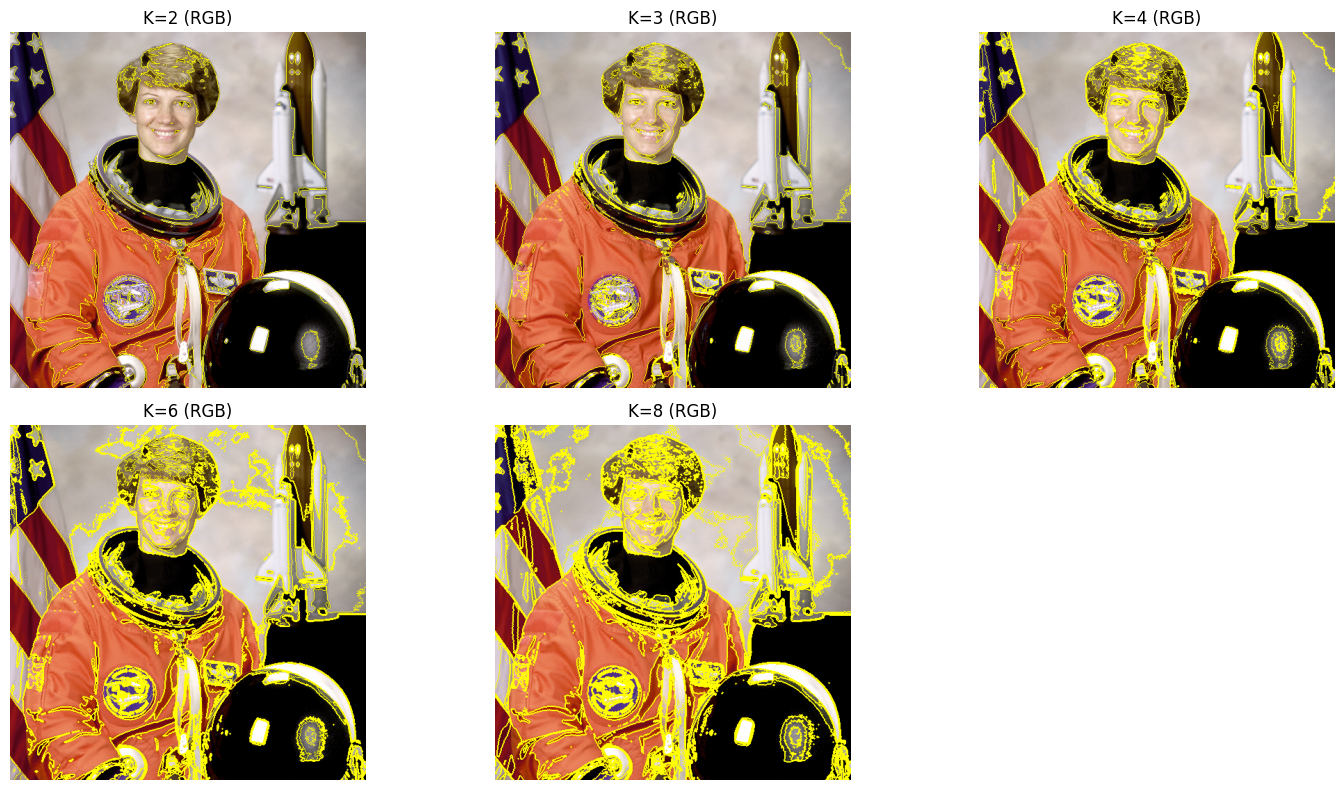


=== Analisis Elbow Method ===


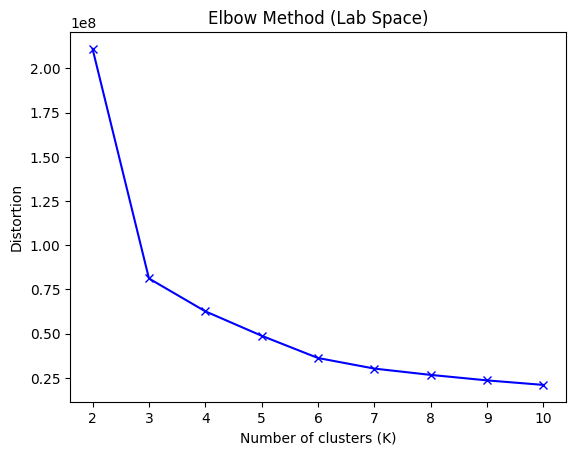

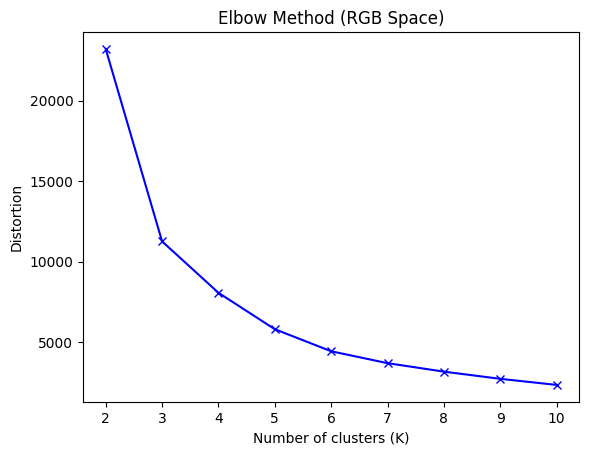

In [6]:
# Soal Praktikum 3
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
from skimage.segmentation import mark_boundaries

# 1. Load image and prepare data
image = data.astronaut()
image_float = image.astype(float) / 255.0

# Prepare both RGB and Lab features
image_lab = rgb2lab(image_float)
rows, cols = image.shape[:2]

# 2. Experiment with different K values
def test_k_values(features, color_space='Lab'):
    plt.figure(figsize=(15, 8))
    
    for i, k in enumerate([2, 3, 4, 6, 8], 1):
        # K-Means clustering
        kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
        labels = kmeans.fit_predict(features)
        segmented = labels.reshape(rows, cols)
        
        # Visualize
        plt.subplot(2, 3, i)
        plt.imshow(mark_boundaries(image, segmented))
        plt.title(f'K={k} ({color_space})')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# 3. Compare color spaces
print("=== Hasil Segmentasi di Ruang Lab ===")
test_k_values(image_lab.reshape(-1, 3), 'Lab')

print("\n=== Hasil Segmentasi di Ruang RGB ===")
test_k_values(image_float.reshape(-1, 3), 'RGB')

# 4. Elbow Method to find optimal K
def plot_elbow_method(features, color_space):
    distortions = []
    K_range = range(2, 11)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, n_init=10)
        kmeans.fit(features)
        distortions.append(kmeans.inertia_)
    
    plt.plot(K_range, distortions, 'bx-')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Distortion')
    plt.title(f'Elbow Method ({color_space} Space)')
    plt.show()

print("\n=== Analisis Elbow Method ===")
plot_elbow_method(image_lab.reshape(-1, 3), 'Lab')
plot_elbow_method(image_float.reshape(-1, 3), 'RGB')

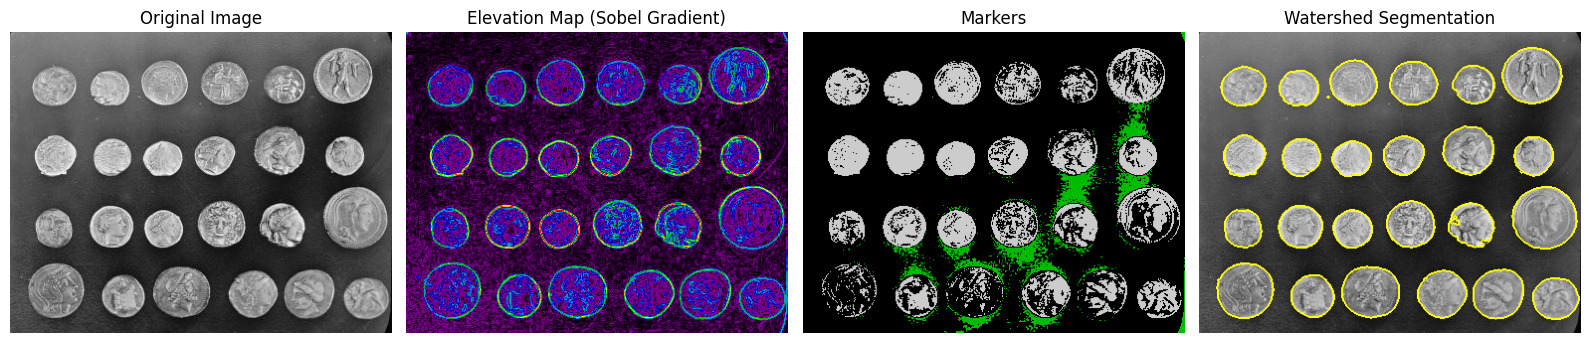

In [ ]:
# Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, measure
from scipy import ndimage as ndi

# 1. Load image (example: coins)
image_coins = data.coins()

# 2. Calculate image gradient (as 'topography')
elevation_map = filters.sobel(image_coins)

# 3. Determine markers (initial seeds for each basin/object)
# Option 1: Simple thresholding for rough markers
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1   # Background marker
markers[image_coins > 150] = 2  # Object (coins) marker

# Option 2: More advanced local maxima markers (commented out)
# from skimage.feature import peak_local_max
# image_max = ndi.maximum_filter(image_coins, size=20, mode='constant')
# coordinates = peak_local_max(image_coins, min_distance=20)
# markers = np.zeros(image_coins.shape, dtype=bool)
# markers[tuple(coordinates.T)] = True
# markers = measure.label(markers)

# 4. Apply Watershed algorithm
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Color the segmentation for visualization
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# 5. Visualize results
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

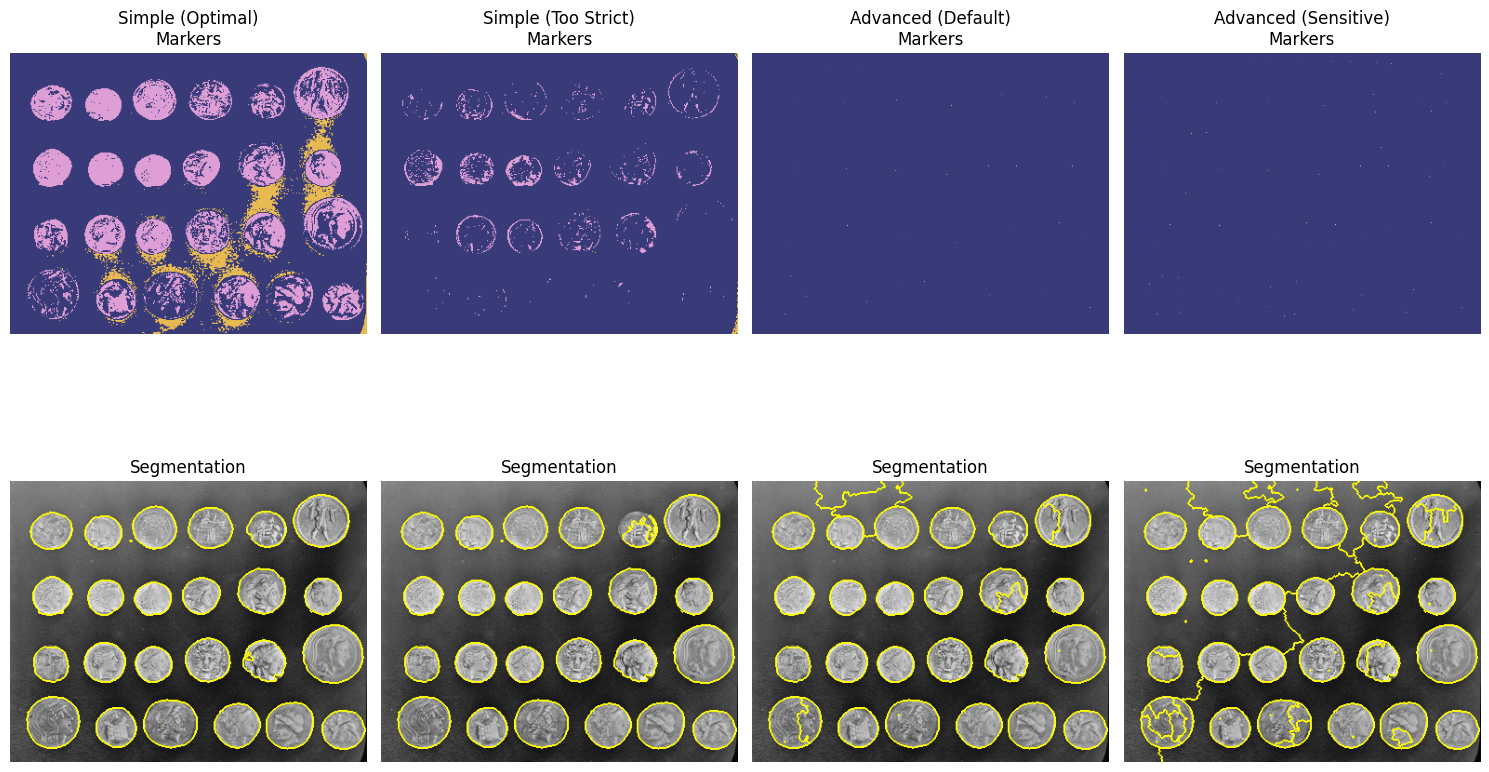

In [ ]:
# Soal Praktikum 4
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure, feature
from scipy import ndimage as ndi

# 1. Load image and calculate gradient
image = data.coins()
elevation_map = filters.sobel(image)

# 2. Define marker generation methods
def simple_threshold_markers(image, bg_thresh=30, obj_thresh=150):
    markers = np.zeros_like(image)
    markers[image < bg_thresh] = 1  # Background
    markers[image > obj_thresh] = 2  # Objects
    return markers

def advanced_markers(image, min_distance=20):
    binary = image > filters.threshold_otsu(image)
    distance = ndi.distance_transform_edt(binary)
    coords = feature.peak_local_max(distance, min_distance=min_distance, labels=binary)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers = measure.label(mask)
    return markers

# 3. Test different parameter sets
parameter_sets = [
    ("Simple (Optimal)", {'method':'simple', 'bg_thresh':30, 'obj_thresh':150}),
    ("Simple (Too Strict)", {'method':'simple', 'bg_thresh':10, 'obj_thresh':200}),
    ("Advanced (Default)", {'method':'advanced', 'min_distance':20}),
    ("Advanced (Sensitive)", {'method':'advanced', 'min_distance':10})
]

# 4. Run experiments
plt.figure(figsize=(15, 10))
for i, (title, params) in enumerate(parameter_sets, 1):
    if params['method'] == 'simple':
        markers = simple_threshold_markers(image, params['bg_thresh'], params['obj_thresh'])
    else:
        markers = advanced_markers(image, params['min_distance'])
    
    seg = segmentation.watershed(elevation_map, markers)
    
    plt.subplot(2, 4, i)
    plt.imshow(markers, cmap='tab20b')
    plt.title(f'{title}\nMarkers')
    plt.axis('off')
    
    plt.subplot(2, 4, i+4)
    plt.imshow(segmentation.mark_boundaries(image, seg))
    plt.title('Segmentation')
    plt.axis('off')

plt.tight_layout()
plt.show()

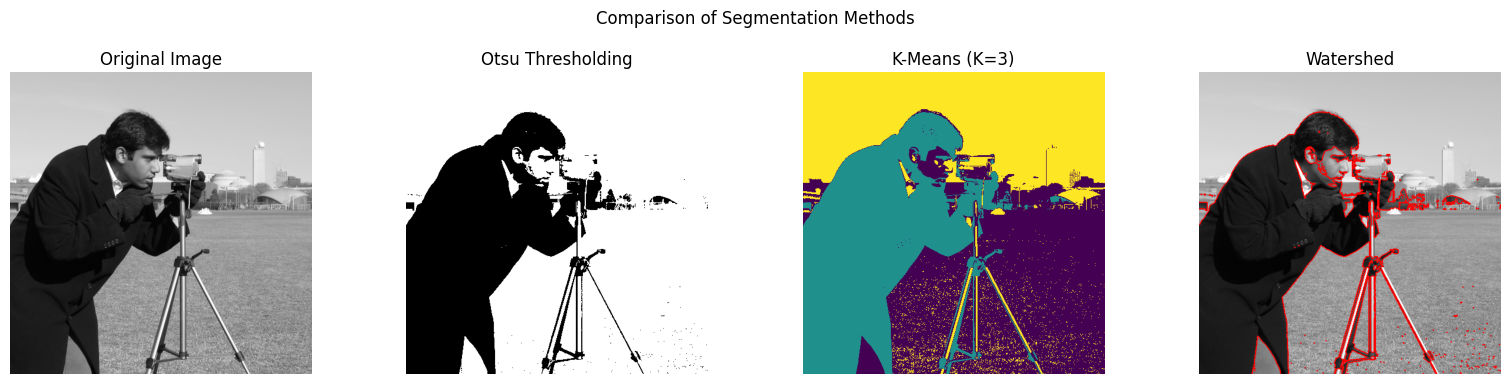

In [ ]:
# Praktikum 5. Perbandingan Visual Hasil Segmentasi
import matplotlib.pyplot as plt
import numpy as np
import warnings
from skimage import data, filters, segmentation, img_as_float
from sklearn.cluster import KMeans

# 1. Load and prepare image
image = data.camera()
image_float = img_as_float(image)
rows, cols = image.shape

# 2. Apply different segmentation methods
# a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means Clustering (K=3)
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed Segmentation
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1  # Background
markers[image > thresh_otsu] = 2  # Foreground
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. Visualize comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

# Original Image
ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

# Otsu Thresholding
ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

# K-Means
ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Watershed
segmented_watershed_colored = segmentation.mark_boundaries(
    image_float, segmentation_watershed, color=(1, 0, 0))  # Red boundaries
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout for title
plt.show()

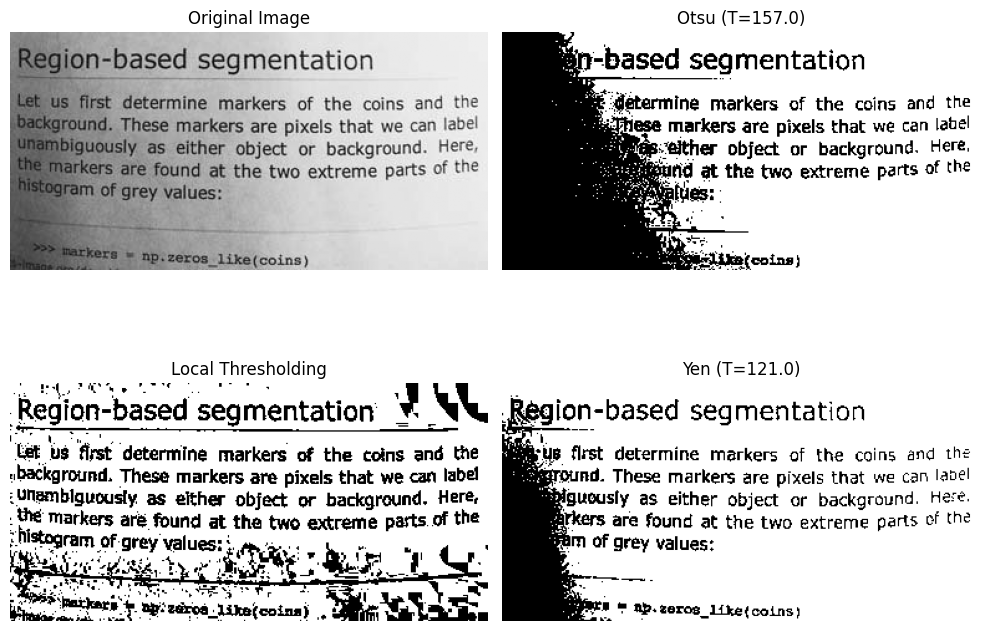

In [ ]:
# Penugasan No 3. Eksperimen Thresholding
import matplotlib.pyplot as plt
from skimage import data, filters
import numpy as np

# Muat citra
image = data.page()
image_float = image.astype(float) / 255.0  # Normalisasi

# A. Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# B. Local Thresholding (Adaptif)
binary_local = image > filters.threshold_local(image, block_size=51, offset=0.1)

# C. Yen Thresholding
thresh_yen = filters.threshold_yen(image)
binary_yen = image > thresh_yen

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title(f'Otsu (T={thresh_otsu:.1f})')
ax[1].axis('off')

ax[2].imshow(binary_local, cmap='gray')
ax[2].set_title('Local Thresholding')
ax[2].axis('off')

ax[3].imshow(binary_yen, cmap='gray')
ax[3].set_title(f'Yen (T={thresh_yen:.1f})')
ax[3].axis('off')

plt.tight_layout()
plt.show()

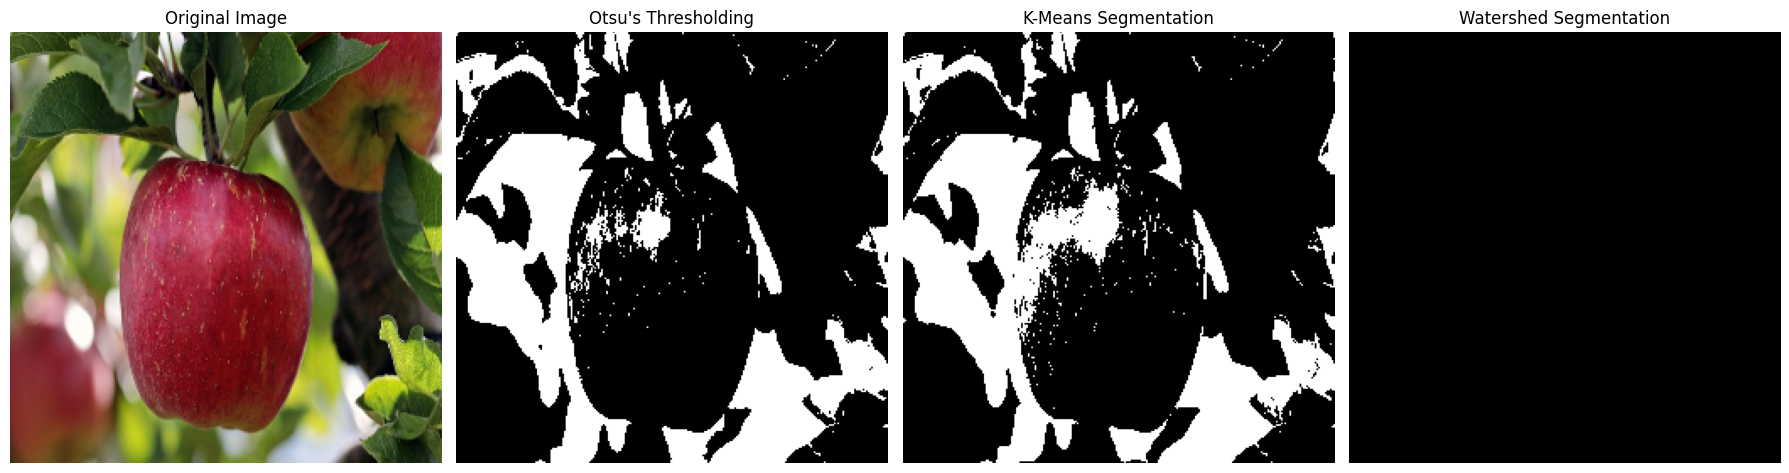

In [20]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi

# Load and convert image
image_path = "apple-2788616_640.jpg"  # Ganti sesuai path gambar Anda
image = Image.open(image_path).convert("RGB")
image_np = np.array(image)

# Resize image for faster processing
image_resized = cv2.resize(image_np, (256, 256))

# Convert to grayscale
gray = cv2.cvtColor(image_resized, cv2.COLOR_RGB2GRAY)

# -----------------------------
# 1. Otsu's Thresholding
# -----------------------------
_, otsu_segmented = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# -----------------------------
# 2. K-Means Segmentation
# -----------------------------
pixels = image_resized.reshape((-1, 3))
kmeans = KMeans(n_clusters=2, random_state=0).fit(pixels)
kmeans_labels = kmeans.labels_.reshape(image_resized.shape[:2])

from skimage.morphology import local_maxima

# -----------------------------
## 3. Watershed Segmentation (updated version)
distance = ndi.distance_transform_edt(cv2.bitwise_not(otsu_segmented))
local_maxi = local_maxima(distance)
markers = ndi.label(local_maxi)[0]
labels_ws = watershed(-distance, markers, mask=otsu_segmented)

# -----------------------------
# Visualization
# -----------------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
axes[0].imshow(image_resized)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(otsu_segmented, cmap='gray')
axes[1].set_title("Otsu's Thresholding")
axes[1].axis("off")

axes[2].imshow(kmeans_labels, cmap='gray')
axes[2].set_title("K-Means Segmentation")
axes[2].axis("off")

axes[3].imshow(labels_ws, cmap='nipy_spectral')
axes[3].set_title("Watershed Segmentation")
axes[3].axis("off")

plt.tight_layout()
plt.show()
